In [20]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import state_fidelity
import matplotlib.pyplot as plt

In [21]:
qc = QuantumCircuit(2) # we are not measuring the circuit
qc.h(0)
qc.cx(0,1)
qc.save_density_matrix()

simulator = AerSimulator()
compiled_circuit = transpile(qc,simulator)
matrix_ideal = simulator.run(compiled_circuit).result().data()['density_matrix']

In [22]:
# simulating distance and noise
distances_meters = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
noise_levels = [d / 100.0 for d in distances_meters]
fidelity_scores = []

In [23]:
for noise in noise_levels:
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise,1), ['h'])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(noise,2), ['cx'])

    sim_noisy = AerSimulator(noise_model=noise_model)
    matrix_noisy = sim_noisy.run(compiled_circuit).result().data()['density_matrix']

    f_score = state_fidelity(matrix_ideal, matrix_noisy)
    fidelity_scores.append(f_score)

Analysis Table
Distance (m)    | Noise Prob.     | Quantum Fidelity
----------------------------------------------------
0               | 0.0             | 1.0000         
10              | 0.1             | 0.8800         
20              | 0.2             | 0.7700         
30              | 0.3             | 0.6700         
40              | 0.4             | 0.5800         
50              | 0.5             | 0.5000         
60              | 0.6             | 0.4300         
70              | 0.7             | 0.3700         
80              | 0.8             | 0.3200         
90              | 0.9             | 0.2800         
100             | 1.0             | 0.2500         


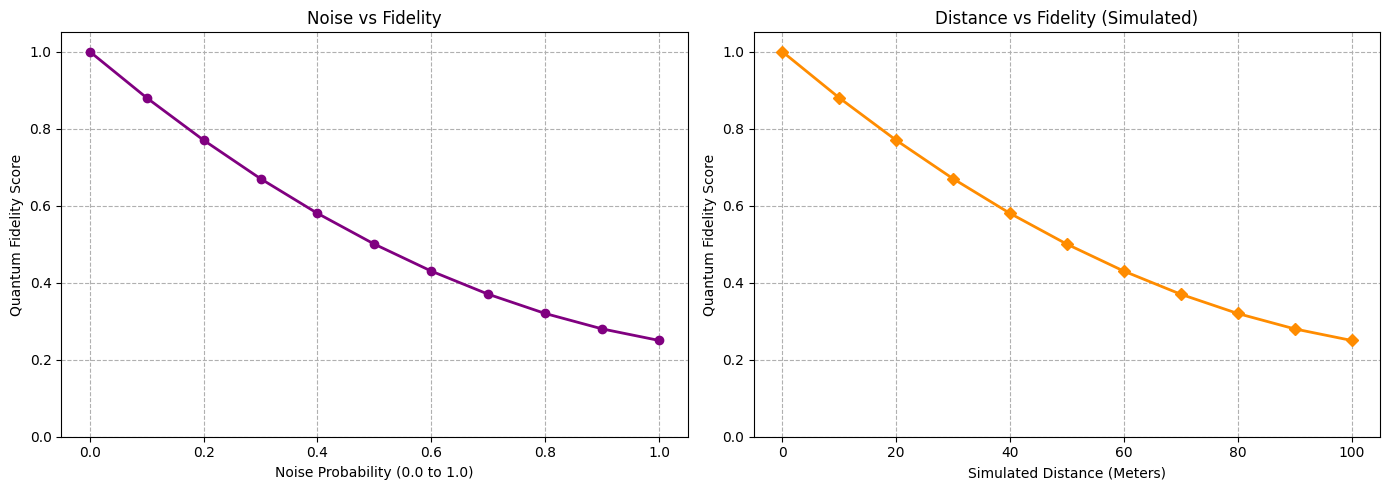

In [24]:
print("Analysis Table")
print(f"{'Distance (m)':<15} | {'Noise Prob.':<15} | {'Quantum Fidelity':<15}")
print("-" * 52)
for d, n, f in zip(distances_meters, noise_levels, fidelity_scores):
    print(f"{d:<15} | {n:<15.1f} | {f:<15.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Noise vs Fidelity
ax1.plot(noise_levels, fidelity_scores, marker='o', color='purple', linewidth=2)
ax1.set_title('Noise vs Fidelity')
ax1.set_xlabel('Noise Probability (0.0 to 1.0)')
ax1.set_ylabel('Quantum Fidelity Score')
ax1.grid(True, linestyle='--')
ax1.set_ylim(0, 1.05)

# Graph 2: Distance vs Fidelity (Simulated)
ax2.plot(distances_meters, fidelity_scores, marker='D', color='darkorange', linewidth=2)
ax2.set_title('Distance vs Fidelity (Simulated)')
ax2.set_xlabel('Simulated Distance (Meters)')
ax2.set_ylabel('Quantum Fidelity Score')
ax2.grid(True, linestyle='--')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()